In [1]:
from IPython.display import HTML
HTML("""
<style>
body { font-size: 10px; }
h1, h2, h3 { color: #ff4da6; }
</style>
""")

<h1 align="center" style="font-size:22pt; font-family:'Georgia',serif; color:#FFFFFF; letter-spacing:1px;">
🫀 Low-Cost AI-Enabled Murmur Analysis Tool
</h1>

<h3 align="center" style="font-size:14pt; font-family:'Georgia',serif; color:#F2F2F2;">
Early Detection of Rheumatic Heart Disease Using PCG Spectrograms
</h3>

<p align="center" style="font-size:12pt; font-family:'Georgia',serif; color:#E8DAEF;">
✨ CNN + BiLSTM • Explainable AI • Research-Grade Pipeline ✨
</p>




In [2]:
import torch

# Check if CUDA is available
print("CUDA Available:", torch.cuda.is_available())

# Get the name of the GPU
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Name: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [3]:
import os

print("Inside 2022 folder:")
print(os.listdir(os.path.join(os.getcwd(), "2022")))

Inside 2022 folder:
['training', 'training_data.csv']


<div style="font-family: Georgia, serif; font-size: 11pt;">

# 🧾 Dataset Collection & Organization

This step prepares a **unified heart sound dataset** from:

- 📁 PhysioNet 2016  
- 📁 PhysioNet 2022  

---

## ⚙️ What it does

- ✅ Loads audio paths and labels  
- ✅ Converts labels → **Normal / Murmur**  
- ✅ Extracts **patient_id** (for leakage-free training)  
- ❌ Excludes validation data (2016)  
- 🔗 Merges both datasets  
- 🧹 Removes duplicates  

---

## 📊 Output

Final dataset saved as: unified_murmur_dataset

</div>

In [ ]:
# ==========================================
# DATASET COLLECTION & ORGANIZATION (FINAL)
# ==========================================

import os
import glob
import pandas as pd

# ------------------------------------------
# STEP 1: BASE PATH
# ------------------------------------------
BASE_DIR = os.getcwd()

PHYSIONET_2016_DIR = os.path.join(BASE_DIR, "data/raw/2016")
PHYSIONET_2022_DIR = os.path.join(BASE_DIR, "data/raw/2022")

print(f"✅ Working Directory: {BASE_DIR}")

# ------------------------------------------
# STEP 2: PARSE PHYSIONET 2016
# ------------------------------------------
def process_physionet_2016(base_path):
    if not os.path.exists(base_path):
        raise FileNotFoundError(f"❌ 2016 dataset not found: {base_path}")

    data_list = []

    # Only include training folders
    folders = [
        f for f in os.listdir(base_path)
        if os.path.isdir(os.path.join(base_path, f)) and "training" in f.lower()
    ]

    print(f"📁 2016 folders used: {folders}")

    for folder in folders:
        folder_path = os.path.join(base_path, folder)

        ref_csv = glob.glob(os.path.join(folder_path, "*.csv"))
        if not ref_csv:
            continue

        df_ref = pd.read_csv(ref_csv[0], names=['filename', 'label'])

        for _, row in df_ref.iterrows():
            wav_name = str(row['filename'])

            if not wav_name.endswith('.wav'):
                wav_name += '.wav'

            audio_path = os.path.join(folder_path, wav_name)

            if os.path.exists(audio_path):
                label = 'Normal' if row['label'] == -1 else 'Murmur'

                data_list.append({
                    'audio_path': audio_path,
                    'dataset_source': f'PhysioNet_2016_{folder}',
                    'label': label,
                    'patient_id': wav_name.split('_')[0]  # fallback grouping
                })

    return pd.DataFrame(data_list)

# ------------------------------------------
# STEP 3: PARSE PHYSIONET 2022
# ------------------------------------------
def process_physionet_2022(base_path):
    if not os.path.exists(base_path):
        raise FileNotFoundError(f"❌ 2022 dataset not found: {base_path}")

    data_list = []

    csv_path = os.path.join(base_path, "training_data.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"❌ training_data.csv not found at {csv_path}")

    df_labels = pd.read_csv(csv_path)
    df_labels.columns = df_labels.columns.str.strip()

    pid_col = 'Patient_ID'
    murmur_col = 'Murmurs'

    for _, row in df_labels.iterrows():
        patient_id = str(row[pid_col])
        murmur_status = str(row[murmur_col]).strip()

        if murmur_status == 'Unknown':
            continue

        label = 'Murmur' if murmur_status == 'Present' else 'Normal'

        wav_paths = glob.glob(
            os.path.join(base_path, "training", f"{patient_id}_*.wav")
        )

        if not wav_paths:
            continue

        for wav_path in wav_paths:
            data_list.append({
                'audio_path': wav_path,
                'dataset_source': 'PhysioNet_2022',
                'label': label,
                'patient_id': patient_id
            })

    return pd.DataFrame(data_list)

# ------------------------------------------
# STEP 4: RUN EXTRACTION
# ------------------------------------------
df_2016 = process_physionet_2016(PHYSIONET_2016_DIR)
print(f"✅ Extracted {len(df_2016)} records from PhysioNet 2016")

df_2022 = process_physionet_2022(PHYSIONET_2022_DIR)
print(f"✅ Extracted {len(df_2022)} records from PhysioNet 2022")

# ------------------------------------------
# STEP 5: MERGE DATASETS
# ------------------------------------------
unified_df = pd.concat([df_2016, df_2022], ignore_index=True)

# Remove duplicate audio paths
unified_df = unified_df.drop_duplicates(subset=['audio_path'])

# ------------------------------------------
# STEP 6: DATASET SUMMARY
# ------------------------------------------
print("\n📊 Final Dataset Distribution:")
print(unified_df['label'].value_counts())

print("\n📊 Source Distribution:")
print(unified_df['dataset_source'].value_counts())

# ------------------------------------------
# STEP 7: SAVE CSV
# ------------------------------------------
output_csv = os.path.join(BASE_DIR, "data/csv/unified_murmur_dataset.csv")
unified_df.to_csv(output_csv, index=False)

print(f"\n✅ Dataset saved at: {output_csv}")

✅ Working Directory: d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM
📁 2016 folders used: ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']
✅ Extracted 3240 records from PhysioNet 2016
✅ Extracted 1604 records from PhysioNet 2022

📊 Final Dataset Distribution:
label
Normal    4179
Murmur     665
Name: count, dtype: int64

📊 Source Distribution:
dataset_source
PhysioNet_2016_training-e    2141
PhysioNet_2022               1604
PhysioNet_2016_training-b     490
PhysioNet_2016_training-a     409
PhysioNet_2016_training-f     114
PhysioNet_2016_training-d      55
PhysioNet_2016_training-c      31
Name: count, dtype: int64

✅ Dataset saved at: d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM\unified_murmur_dataset.csv


<div style="font-family: Georgia, serif; font-size: 11pt;">

## 📊 Label Distribution

The bar chart illustrates the distribution of Normal and Murmur samples in the dataset.

---

### 🔍 Interpretation

- The dataset is **highly imbalanced**:
  - 🟢 **Normal samples** are significantly higher  
  - 🔴 **Murmur samples** are much fewer  

- This reflects real-world medical scenarios where abnormal cases are less frequent.

---

### ⚠️ Implication

- The model may become **biased toward predicting Normal**
- To address this, we incorporate:
  - ✅ Class weighting during training  
  - ✅ Recall-focused evaluation (important for murmur detection)

---

✨ This analysis highlights the importance of handling class imbalance in the model.

</div>

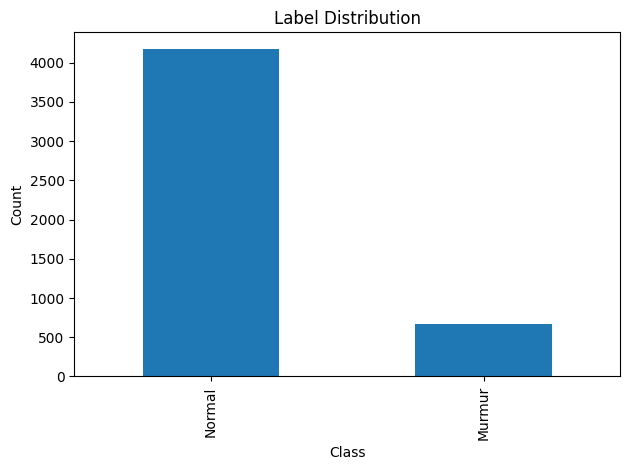

In [5]:
import matplotlib.pyplot as plt

plt.figure()
unified_df['label'].value_counts().plot(kind='bar')

plt.title("Label Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🎧 Audio Preprocessing

Standardizes and cleans PCG signals for model-ready input.

---

### ⚙️ Key Steps
- Resample to **2000 Hz**
- Apply **bandpass filter (20–400 Hz)**
- Normalize amplitude
- Remove very short/corrupt files
- Save cleaned audio

---

### 📦 Output
- 📁 `processed_audio/`
- 📄 `preprocessed_dataset.csv`  
  (includes `clean_audio_path`, label, source, patient_id)

---

### 🔍 Summary
- ✔ Clean, standardized signals  
- ❌ Invalid files removed  
- 🎯 Ready for feature extraction  

</div>

In [ ]:
# ==========================================
# AUDIO PREPROCESSING (FINAL OPTIMIZED)
# ==========================================

import os
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
from scipy.signal import butter, filtfilt
from tqdm import tqdm

# ------------------------------------------
# CONFIG
# ------------------------------------------
BASE_DIR = "."

INPUT_CSV = os.path.join(BASE_DIR, "data/csv/unified_murmur_dataset.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "data/processed/processed_audio")
OUTPUT_CSV = os.path.join(BASE_DIR, "data/csv/preprocessed_dataset.csv")

TARGET_SR = 2000
LOWCUT = 20.0
HIGHCUT = 400.0
FILTER_ORDER = 4

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("data/csv", exist_ok=True)

# ------------------------------------------
# FILTER FUNCTION
# ------------------------------------------
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = max(lowcut / nyq, 0.001)
    high = min(highcut / nyq, 0.99)

    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

# ------------------------------------------
# PREPROCESS FUNCTION
# ------------------------------------------
def preprocess_audio(file_path, save_path):
    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None, mono=True)

        # Handle short audio (pad instead of skipping)
        if len(y) < sr:
            y = np.pad(y, (0, sr - len(y)))

        # Resample
        if sr != TARGET_SR:
            y = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)

        # Bandpass filter
        y = butter_bandpass_filter(y, LOWCUT, HIGHCUT, TARGET_SR, FILTER_ORDER)

        # Normalize
        max_val = np.max(np.abs(y))
        if max_val > 0:
            y = y / max_val

        # Save as WAV
        sf.write(save_path, y, TARGET_SR)

        return True

    except Exception as e:
        print(f"❌ Error processing {file_path}: {e}")
        return False

# ------------------------------------------
# MAIN EXECUTION
# ------------------------------------------
df = pd.read_csv(INPUT_CSV)

processed_paths = []
valid_indices = []
failed_files = []

print(f"🚀 Processing {len(df)} files...")

for index in tqdm(range(len(df))):
    row = df.iloc[index]

    orig_path = row['audio_path']
    filename = os.path.basename(orig_path)

    # Ensure proper .wav output name
    name = os.path.splitext(filename)[0]
    save_filename = f"clean_{index}_{name}.wav"
    save_path = os.path.join(OUTPUT_DIR, save_filename)

    success = preprocess_audio(orig_path, save_path)

    if success:
        processed_paths.append(save_path)
        valid_indices.append(index)
    else:
        failed_files.append(orig_path)

# ------------------------------------------
# BUILD CLEAN DATASET
# ------------------------------------------
df_clean = df.loc[valid_indices].copy()
df_clean['clean_audio_path'] = processed_paths

df_clean.to_csv(OUTPUT_CSV, index=False)

# ------------------------------------------
# SUMMARY
# ------------------------------------------
print("\n✅ Preprocessing complete")
print(f"✔ Processed files: {len(df_clean)}")
print(f"❌ Failed files: {len(failed_files)}")
print(f"⚠️ Failure rate: {len(failed_files)/len(df)*100:.2f}%")
print(f"📁 Output folder: {OUTPUT_DIR}")
print(f"📄 CSV saved at: {OUTPUT_CSV}")

🚀 Processing 4844 files...


  0%|          | 0/4844 [00:00<?, ?it/s]

100%|██████████| 4844/4844 [00:20<00:00, 234.55it/s]


✅ Preprocessing complete
✔ Processed files: 4844
❌ Failed files: 0
⚠️ Failure rate: 0.00%
📁 Output folder: .\processed_audio
📄 CSV saved at: .\preprocessed_dataset.csv


<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🎧 Waveform Comparison

- Original signal contains noise and varying amplitude  
- Processed signal is cleaner and normalized  
- Heart sound peaks are more clearly visible  

---

✨ Confirms improved signal quality for model input.

</div>

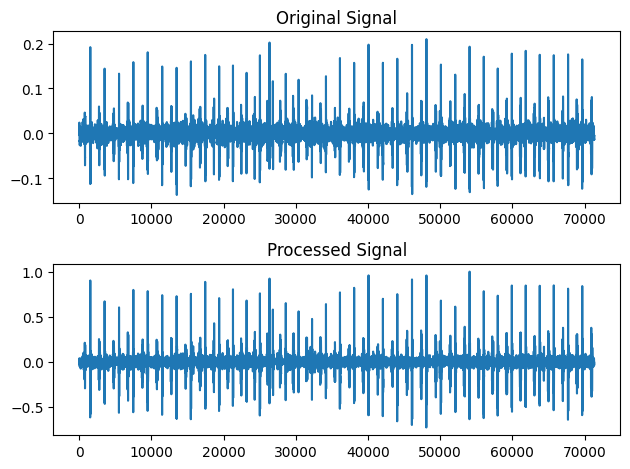

In [7]:
import matplotlib.pyplot as plt
import librosa

orig = unified_df.iloc[0]['audio_path']
clean = df_clean.iloc[0]['clean_audio_path']

y1, sr1 = librosa.load(orig, sr=None)
y2, sr2 = librosa.load(clean, sr=None)

plt.figure()

plt.subplot(2,1,1)
plt.plot(y1)
plt.title("Original Signal")

plt.subplot(2,1,2)
plt.plot(y2)
plt.title("Processed Signal")

plt.tight_layout()
plt.show()

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 📊 Frequency Spectrum (Before vs After Filtering)

The plot compares the frequency content of the signal before and after applying the bandpass filter.

---

### 🔍 Interpretation

- Before filtering: energy is spread across a wide frequency range, including noise  
- After filtering: frequencies above ~400 Hz are removed  
- Signal energy is concentrated in the **0–200 Hz range**, relevant to heart sounds  

---

✨ Confirms effective noise removal and retention of important cardiac frequencies.

</div>

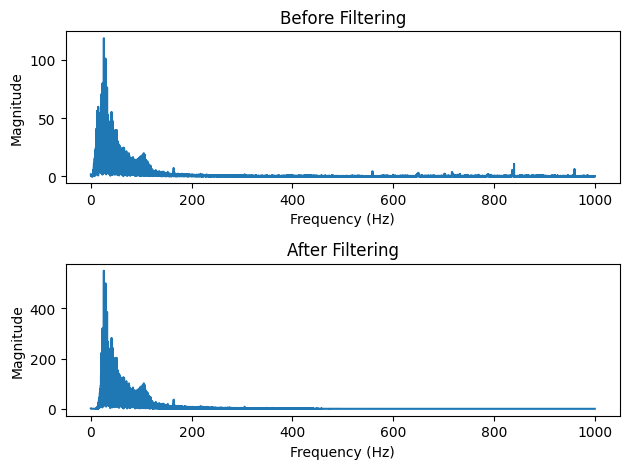

In [8]:
import numpy as np

def plot_fft(signal, sr, title):
    fft = np.abs(np.fft.rfft(signal))
    freq = np.fft.rfftfreq(len(signal), 1/sr)

    plt.plot(freq, fft)
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")

plt.figure()

plt.subplot(2,1,1)
plot_fft(y1, sr1, "Before Filtering")

plt.subplot(2,1,2)
plot_fft(y2, sr2, "After Filtering")

plt.tight_layout()
plt.show()

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🧩 Segmentation & Feature Extraction

This step converts cleaned audio into fixed-size spectrogram features for model training.

---

### ⚙️ What it does

- ✂️ Splits audio into **3-second segments**
- 🎼 Converts each segment into **Mel Spectrograms (128 bands)**
- 📏 Ensures **fixed-size input (padding/trimming)**
- 💾 Saves features as `.npy` files
- 🔗 Maintains `patient_id` for leakage-free training  

---

### 📦 Output

- 📁 `spectrograms/` (feature files)  
- 📄 `final_training_dataset.csv`  
  (includes `spectrogram_path`, label, patient_id, source)

---

### 🔍 Summary

- ✔ Uniform input shape for model  
- ✔ Temporal segmentation improves learning  
- ✔ Converts audio → image-like representation  

---

✨ Enables deep learning models to capture heart sound patterns effectively.

</div>

In [ ]:
# ==========================================
# SEGMENTATION & FEATURE EXTRACTION (FINAL)
# ==========================================

import os
import pandas as pd
import numpy as np
import librosa
from tqdm import tqdm

BASE_DIR = "."
INPUT_CSV = os.path.join(BASE_DIR, "data/csv/preprocessed_dataset.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "data/spectrograms")
OUTPUT_CSV = os.path.join(BASE_DIR, "data/csv/final_training_dataset.csv")

TARGET_SR = 2000
CHUNK_LENGTH_SEC = 3.0
CHUNK_SAMPLES = int(TARGET_SR * CHUNK_LENGTH_SEC)

N_MELS = 128
HOP_LENGTH = 64
N_FFT = 512

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("data/csv", exist_ok=True)

# ------------------------------------------
# MEL SPECTROGRAM
# ------------------------------------------
def extract_mel_spectrogram(y, sr):
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT,
        hop_length=HOP_LENGTH, n_mels=N_MELS
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db

# ------------------------------------------
# FIXED SIZE FUNCTION
# ------------------------------------------
def pad_or_trim(spec, target_width=94):
    if spec.shape[1] < target_width:
        pad_width = target_width - spec.shape[1]
        spec = np.pad(spec, ((0, 0), (0, pad_width)), mode='constant')
    else:
        spec = spec[:, :target_width]
    return spec

# ------------------------------------------
# MAIN
# ------------------------------------------
df = pd.read_csv(INPUT_CSV)

segment_data = []

print("Starting feature extraction...")

for index in tqdm(range(len(df))):
    row = df.iloc[index]

    audio_path = row['clean_audio_path']
    label = row['label']
    source = row['dataset_source']
    patient_id = row['patient_id']   # 🔥 critical

    try:
        y, sr = librosa.load(audio_path, sr=None)

        total_samples = len(y)
        num_chunks = total_samples // CHUNK_SAMPLES

        if num_chunks == 0:
            y = np.pad(y, (0, CHUNK_SAMPLES - total_samples))
            spec = extract_mel_spectrogram(y, sr)
            spec = pad_or_trim(spec)

            save_path = os.path.join(OUTPUT_DIR, f"spec_{index}_0.npy")
            np.save(save_path, spec)

            segment_data.append({
                'spectrogram_path': save_path,
                'label': label,
                'patient_id': patient_id,
                'source': source
            })

        else:
            for i in range(num_chunks):
                start = i * CHUNK_SAMPLES
                end = start + CHUNK_SAMPLES

                chunk = y[start:end]

                spec = extract_mel_spectrogram(chunk, sr)
                spec = pad_or_trim(spec)

                save_path = os.path.join(OUTPUT_DIR, f"spec_{index}_{i}.npy")
                np.save(save_path, spec)

                segment_data.append({
                    'spectrogram_path': save_path,
                    'label': label,
                    'patient_id': patient_id,
                    'source': source
                })

    except:
        continue

# Save dataset
df_segments = pd.DataFrame(segment_data)
df_segments.to_csv(OUTPUT_CSV, index=False)

print(f"\n✅ Total segments: {len(df_segments)}")
print(df_segments['label'].value_counts())

Starting feature extraction...


100%|██████████| 4844/4844 [01:31<00:00, 52.79it/s]


✅ Total segments: 33881
label
Normal    28616
Murmur     5265
Name: count, dtype: int64


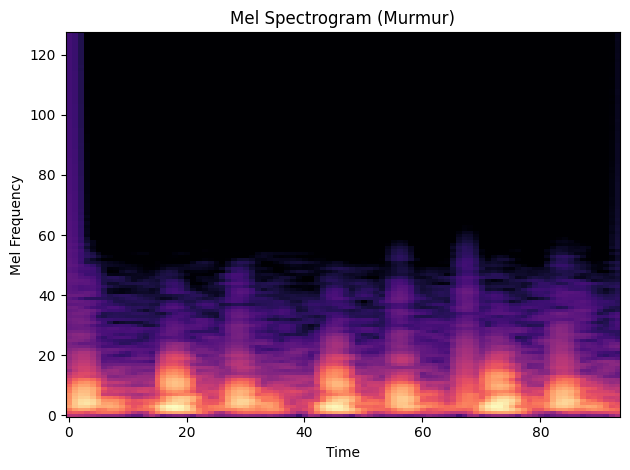

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data/csv/final_training_dataset.csv")

sample = df.sample(1).iloc[0]
spec = np.load(sample['spectrogram_path'])

plt.figure()
plt.imshow(spec, aspect='auto', origin='lower', cmap='magma')
plt.title(f"Mel Spectrogram ({sample['label']})")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

plt.tight_layout()
plt.show()

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🧠 Model Training (CNN)

This stage trains a CNN model on spectrogram features for murmur classification.

---

### ⚙️ Key Steps

- 🔀 **Patient-wise split** (prevents data leakage)  
- ⚖️ **Class weighting** to handle imbalance  
- 📦 **Batch generator** for efficient loading  
- 🧠 CNN with Conv + BatchNorm + Pooling layers  
- 🎯 Output: Binary classification (Normal / Murmur)  

---

### 📊 Training Strategy

- Loss: **Binary Crossentropy**  
- Metrics: **Accuracy, Recall, AUC**  
- Optimizer: **Adam (lr = 1e-4)**  
- Early stopping + best model checkpoint  

---

### 📦 Output

- 💾 Best model saved as:murmur_cnn_keras

In [ ]:
# ==========================================
# 4. MODEL TRAINING (FINAL CLEAN VERSION)
# ==========================================

import os
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
os.makedirs("models", exist_ok=True)

# ------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------
# CONFIG
# ------------------------------------------
CSV_PATH = "data/csv/final_training_dataset.csv"
BATCH_SIZE = 32
EPOCHS = 50

# ------------------------------------------
# LOAD DATA
# ------------------------------------------
df = pd.read_csv(CSV_PATH)
df['label_encoded'] = df['label'].apply(lambda x: 0 if x == 'Normal' else 1)

# ------------------------------------------
# PATIENT-WISE SPLIT
# ------------------------------------------
patient_df = df[['patient_id', 'label_encoded']].drop_duplicates()

train_patients, val_patients = train_test_split(
    patient_df,
    test_size=0.2,
    stratify=patient_df['label_encoded'],
    random_state=SEED
)

train_df = df[df['patient_id'].isin(train_patients['patient_id'])]
val_df = df[df['patient_id'].isin(val_patients['patient_id'])]

print(f"Train samples: {len(train_df)} | Val samples: {len(val_df)}")

# ------------------------------------------
# CLASS WEIGHTS
# ------------------------------------------
y_train = train_df['label_encoded'].values
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: class_weights_array[0], 1: class_weights_array[1]}

# ------------------------------------------
# DATA GENERATOR
# ------------------------------------------
class SpectrogramGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size=32, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_idx = self.indices[index*self.batch_size:(index+1)*self.batch_size]
        batch = self.df.iloc[batch_idx]

        X, y = [], []

        for row in batch.itertuples():
            spec = np.load(row.spectrogram_path)

            # Normalization
            spec = (spec - np.mean(spec)) / (np.std(spec) + 1e-6)

            spec = np.expand_dims(spec, axis=-1)

            X.append(spec)
            y.append(row.label_encoded)

        return np.array(X), np.array(y)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

# Generators
train_gen = SpectrogramGenerator(train_df, BATCH_SIZE, shuffle=True)
val_gen = SpectrogramGenerator(val_df, BATCH_SIZE, shuffle=False)

# Input shape
sample_X, _ = train_gen[0]
input_shape = sample_X[0].shape

print("Input shape:", input_shape)

# ------------------------------------------
# FOCAL LOSS
# ------------------------------------------
def focal_loss(gamma=2., alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        return alpha * tf.pow((1 - p_t), gamma) * bce
    return loss

# ------------------------------------------
# MODEL: CNN + BiLSTM + ATTENTION
# ------------------------------------------
def build_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # CNN
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Reshape for sequence
    x = layers.Permute((2,1,3))(x)
    x = layers.Reshape((11, 16 * 128))(x)

    # BiLSTM
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True)
    )(x)

    # Attention
    attention = layers.Dense(1, activation='tanh')(x)
    attention = layers.Softmax(axis=1)(attention)
    x = layers.Multiply()([x, attention])

    # ✅ FINAL FIX (NO LAMBDA)
    x = layers.GlobalAveragePooling1D()(x)

    # Classifier
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss=focal_loss(),
        metrics=[
            'accuracy',
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model

model = build_model(input_shape)
model.summary()

# ------------------------------------------
# TRAINING
# ------------------------------------------
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.ModelCheckpoint(
            "models/cnn_bilstm_attention_best.keras",
            monitor='val_recall',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=7,
            restore_best_weights=True
        )
    ]
)

# Save final model
model.save("models/cnn_bilstm_attention_final.keras")

print("\n✅ Training complete")

Train samples: 26996 | Val samples: 6885
Input shape: (128, 94, 1)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 94,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 94,   │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 94,   │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 47,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 47,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 47,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 32, 23,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 23,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 23,    │        512 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 16, 11,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute_1 (Permute) │ (None, 11, 16,    │          0 │ max_pooling2d_11… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 11, 2048)  │          0 │ permute_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 11, 256)   │  2,229,248 │ reshape_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 11, 1)     │        257 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 11, 1)     │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 11, 256)   │          0 │ bidirectional_1[… │
│ (Multiply)          │                   │            │ softmax_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │     16,448 │ global_average_p

 Total params: 2,339,586 (8.92 MB)

 Trainable params: 2,339,138 (8.92 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/50


d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM\RHD_detection\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8751 - auc: 0.8817 - loss: 0.0461 - precision: 0.5804 - recall: 0.6340
Epoch 1: val_recall improved from None to 0.73056, saving model to cnn_bilstm_attention_best.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 184s 213ms/step - accuracy: 0.8990 - auc: 0.9340 - loss: 0.0276 - precision: 0.6422 - recall: 0.7873 - val_accuracy: 0.9239 - val_auc: 0.9639 - val_loss: 0.0324 - val_precision: 0.7720 - val_recall: 0.7306
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9183 - auc: 0.9612 - loss: 0.0137 - precision: 0.6858 - recall: 0.8666
Epoch 2: val_recall improved from 0.73056 to 0.86019, saving model to cnn_bilstm_attention_best.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 167s 198ms/step - accuracy: 0.9210 - auc: 0.9646 - loss: 0.0129 - precision: 0.6957 - recall: 0.8710 - val_accuracy: 0.9114 - val_auc: 0.9692 - val_loss: 0.0282 - val_precision: 0.6693 - val_recall: 0.8602
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accura

In [19]:
# ------------------------------------------
# FINAL EVALUATION
# ------------------------------------------
print("\n📊 Evaluating model on validation set...")

results = model.evaluate(val_gen, verbose=0)

# Extract metrics
loss = results[0]
accuracy = results[1]
recall = results[2]
precision = results[3]
auc = results[4]

print("\n✅ Final Metrics:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"Precision : {precision:.4f}")
print(f"AUC       : {auc:.4f}")


📊 Evaluating model on validation set...

✅ Final Metrics:
Accuracy  : 0.9288
Recall    : 0.7926
Precision : 0.7629
AUC       : 0.9733


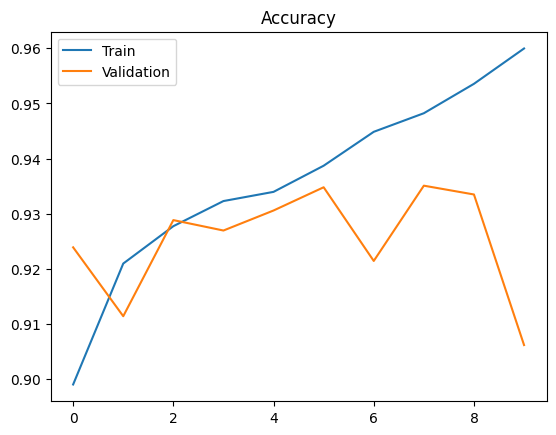

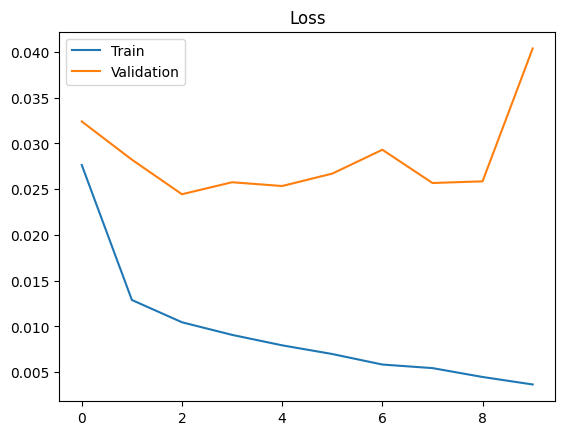

In [20]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()
plt.show()

Loading CNN-BiLSTM-Attention model...

Evaluating on validation set...
216/216 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step

VALIDATION CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (0)       0.99      0.90      0.94      5805
  Murmur (1)       0.63      0.95      0.76      1080

    accuracy                           0.91      6885
   macro avg       0.81      0.92      0.85      6885
weighted avg       0.93      0.91      0.91      6885



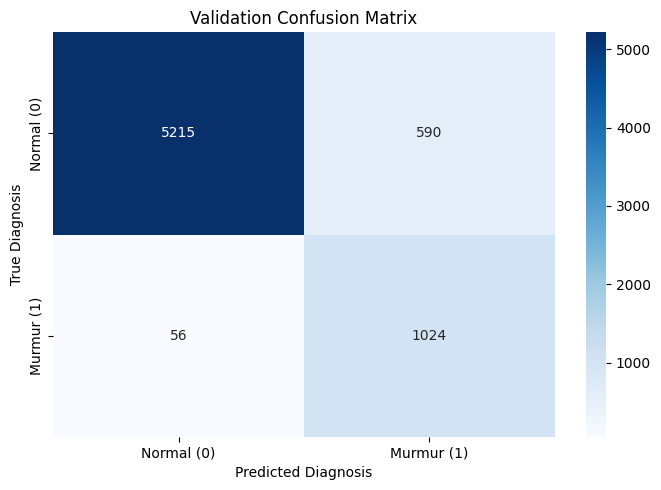

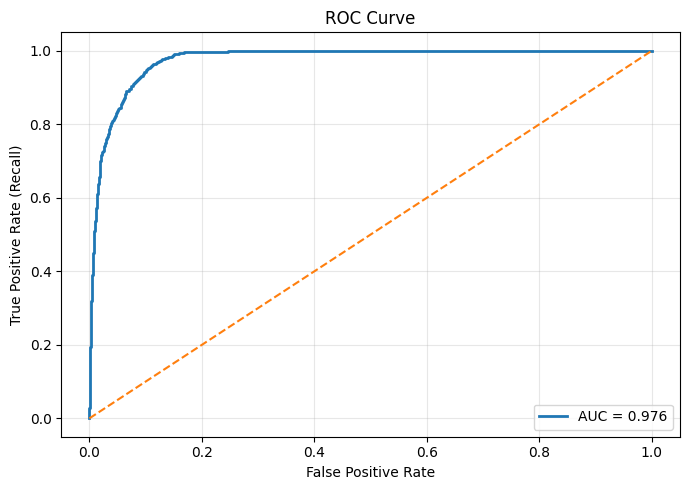


Evaluating on training set...
  3/844 ━━━━━━━━━━━━━━━━━━━━ 31s 37ms/step 

d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM\RHD_detection\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


844/844 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step

TRAINING CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Normal (0)       1.00      0.91      0.95     22811
  Murmur (1)       0.67      1.00      0.80      4185

    accuracy                           0.92     26996
   macro avg       0.83      0.95      0.87     26996
weighted avg       0.95      0.92      0.93     26996



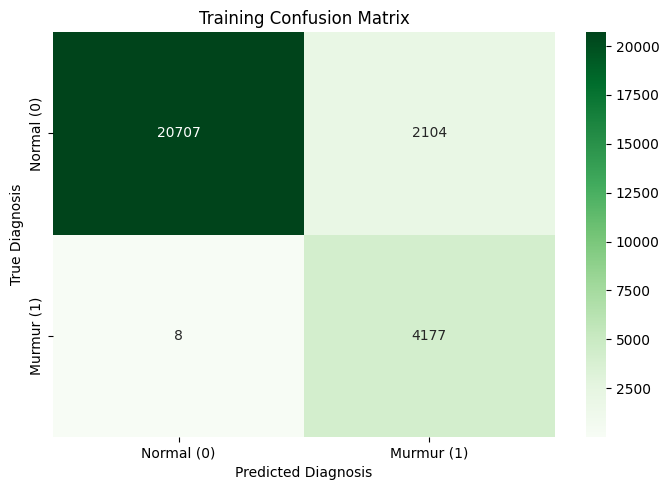

In [ ]:
# ==========================================
# 5. MODEL EVALUATION (FINAL CLEAN VERSION)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf

# ------------------------------------------
# 🔥 FOCAL LOSS (ONLY if model used it)
# ------------------------------------------
def focal_loss(gamma=2., alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        return alpha * tf.pow((1 - p_t), gamma) * bce
    return loss

# ------------------------------------------
# ✅ LOAD MODEL (NOW SIMPLE)
# ------------------------------------------
print("Loading CNN-BiLSTM-Attention model...")

best_model = tf.keras.models.load_model(
    "models/cnn_bilstm_attention_best.keras",
    custom_objects={'loss': focal_loss()},
    compile=False
)

# 🔥 Recompile (safer)
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_loss(),
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# ------------------------------------------
# VALIDATION SET
# ------------------------------------------
print("\nEvaluating on validation set...")

y_true = val_gen.df['label_encoded'].values

y_pred_probs = best_model.predict(val_gen).flatten()
y_pred_classes = (y_pred_probs > 0.5).astype(int)

# ------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------
print("\n" + "="*50)
print("VALIDATION CLASSIFICATION REPORT")
print("="*50)

target_names = ['Normal (0)', 'Murmur (1)']
print(classification_report(y_true, y_pred_classes, target_names=target_names))

# ------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)

plt.title('Validation Confusion Matrix')
plt.ylabel('True Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.tight_layout()
plt.show()

# ------------------------------------------
# ROC CURVE
# ------------------------------------------
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# TRAINING SET EVALUATION
# ==========================================

print("\nEvaluating on training set...")

train_gen_eval = SpectrogramGenerator(train_df, batch_size=BATCH_SIZE, shuffle=False)

y_true_train = train_gen_eval.df['label_encoded'].values

y_pred_probs_train = best_model.predict(train_gen_eval).flatten()
y_pred_classes_train = (y_pred_probs_train > 0.5).astype(int)

print("\n" + "="*50)
print("TRAINING CLASSIFICATION REPORT")
print("="*50)

print(classification_report(y_true_train, y_pred_classes_train, target_names=target_names))

# ------------------------------------------
# TRAINING CONFUSION MATRIX
# ------------------------------------------
cm_train = confusion_matrix(y_true_train, y_pred_classes_train)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names,
            yticklabels=target_names)

plt.title('Training Confusion Matrix')
plt.ylabel('True Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import os

print("Current Working Directory:", os.getcwd())

try:
    df_old = pd.read_csv("data/csv/preprocessed_dataset.csv")
    print(f"preprocessed_dataset.csv has {len(df_old)} rows.")
except Exception as e:
    print(f"Error loading preprocessed_dataset.csv: {e}")

try:
    df_new = pd.read_csv("data/csv/final_training_dataset.csv")
    print(f"final_training_dataset.csv has {len(df_new)} rows.")
except Exception as e:
    print(f"Error loading final_training_dataset.csv: {e}")

Current Working Directory: d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM
preprocessed_dataset.csv has 4844 rows.
final_training_dataset.csv has 33881 rows.


<div style="font-family: Georgia, serif; font-size: 11pt;">

## ❤️ S1 & S2 Segmentation

Identifies heart sound phases using Shannon Energy.

---

### ⚙️ Key Steps
- Normalize audio  
- Compute & smooth energy  
- Detect peaks → **S1, S2**  
- Classify:
  - Systole (short gap)  
  - Diastole (long gap)  

---

### 🔍 Interpretation
- Peaks = heart sounds  
- Gap length → phase identification  

---

✨ Enables clear temporal analysis of cardiac cycles.

</div>

Checking file: ./processed_audio/clean_4775_85279_TV.wav
Exists: True


d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM\RHD_detection\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Audio length: 62784
Max amplitude: 0.9999695
Peaks detected: 99


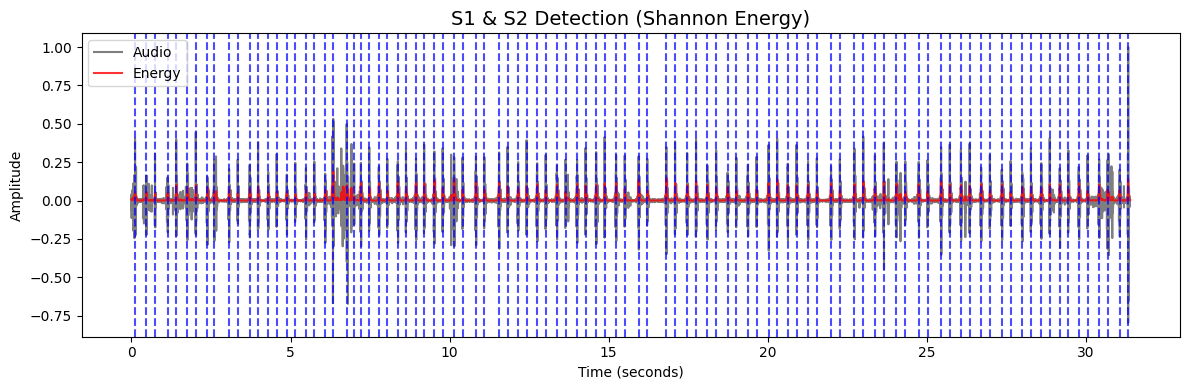


--- Detected Heart Phases ---
Systole (S1→S2): 0.11s → 0.47s
Systole (S1→S2): 0.47s → 0.74s
Systole (S1→S2): 0.74s → 1.14s
Systole (S1→S2): 1.14s → 1.41s
Systole (S1→S2): 1.41s → 1.75s


In [ ]:
# ==========================================
# S1, S2, Systole & Diastole Segmentation
# (FINAL WORKING VERSION)
# ==========================================

import numpy as np
import librosa
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

# ------------------------------------------
# SEGMENTATION FUNCTION
# ------------------------------------------
def segment_heart_sounds(y, sr):

    # Normalize safely
    y_norm = y / (np.max(np.abs(y)) + 1e-8)

    # Shannon Energy
    energy = -(y_norm**2) * np.log(y_norm**2 + 1e-10)

    # Smooth (20 ms window)
    window_len = int(sr * 0.02)
    smoothed_energy = np.convolve(
        energy,
        np.ones(window_len)/window_len,
        mode='same'
    )

    # Peak detection (robust threshold)
    distance = int(sr * 0.2)
    threshold = np.mean(smoothed_energy)

    peaks, _ = find_peaks(
        smoothed_energy,
        distance=distance,
        height=threshold
    )

    # Safety check
    if len(peaks) < 2:
        return smoothed_energy, peaks, []

    # Phase classification
    phases = []
    for i in range(len(peaks) - 1):
        gap = peaks[i+1] - peaks[i]

        if gap < (sr * 0.4):
            label = 'Systole (S1→S2)'
        else:
            label = 'Diastole (S2→S1)'

        phases.append({
            'start': peaks[i],
            'end': peaks[i+1],
            'label': label
        })

    return smoothed_energy, peaks, phases


# ------------------------------------------
# TEST AUDIO
# ------------------------------------------
test_audio_path = "data/processed/processed_audio/clean_4775_85279_TV.wav"

print("Checking file:", test_audio_path)
print("Exists:", os.path.exists(test_audio_path))

# Load audio
y, sr = librosa.load(test_audio_path, sr=2000)

print("Audio length:", len(y))
print("Max amplitude:", np.max(np.abs(y)))

# Run segmentation
energy, peaks, phases = segment_heart_sounds(y, sr)

print("Peaks detected:", len(peaks))

# ------------------------------------------
# VISUALIZATION
# ------------------------------------------
time_axis = np.linspace(0, len(y)/sr, len(y))

plt.figure(figsize=(12, 4))

# Raw waveform
plt.plot(time_axis, y, color='black', alpha=0.5, label='Audio')

# Energy
plt.plot(time_axis, energy, color='red', alpha=0.8, label='Energy')

# Peaks (S1/S2)
for p in peaks:
    plt.axvline(x=p/sr, color='blue', linestyle='--', alpha=0.7)

plt.title("S1 & S2 Detection (Shannon Energy)", fontsize=14)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()

plt.tight_layout()
plt.show()

# ------------------------------------------
# PRINT PHASES
# ------------------------------------------
print("\n--- Detected Heart Phases ---")

if len(phases) == 0:
    print("⚠️ Not enough peaks detected")
else:
    for phase in phases[:5]:
        start = phase['start'] / sr
        end = phase['end'] / sr
        print(f"{phase['label']}: {start:.2f}s → {end:.2f}s")

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🔍 Model Prediction & Explainability

This stage combines model prediction with signal-level and visual explanations.

---

### ⚙️ What it shows

- ❤️ **S1/S2 Detection** → highlights heart sound peaks  
- 🎼 **Mel Spectrogram** → time-frequency representation  
- 🔥 **GradCAM** → regions influencing the model decision  
- 🧠 Final prediction with confidence score  

---

### 🔍 Interpretation

- Model predicts **Murmur Detected (high confidence)**  
- Peaks align with cardiac cycles (S1/S2)  
- Spectrogram shows energy concentration in heart sound range  
- GradCAM highlights regions used by the model for prediction  

---

### 🎯 Significance

- ✔ Combines **signal + model + explainability**  
- ✔ Makes predictions **interpretable and trustworthy**  
- ✔ Useful for clinical understanding  

---

✨ Provides an end-to-end interpretable murmur detection system.

</div>


Using sample:
Spectrogram: .\spectrograms\spec_96_6.npy
Audio: ./processed_audio\clean_96_a0097.wav

Processing: clean_96_a0097.wav


d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM\RHD_detection\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer_3']
Received: inputs=Tensor(shape=(1, 128, 94, 1))
  warnings.warn(msg)


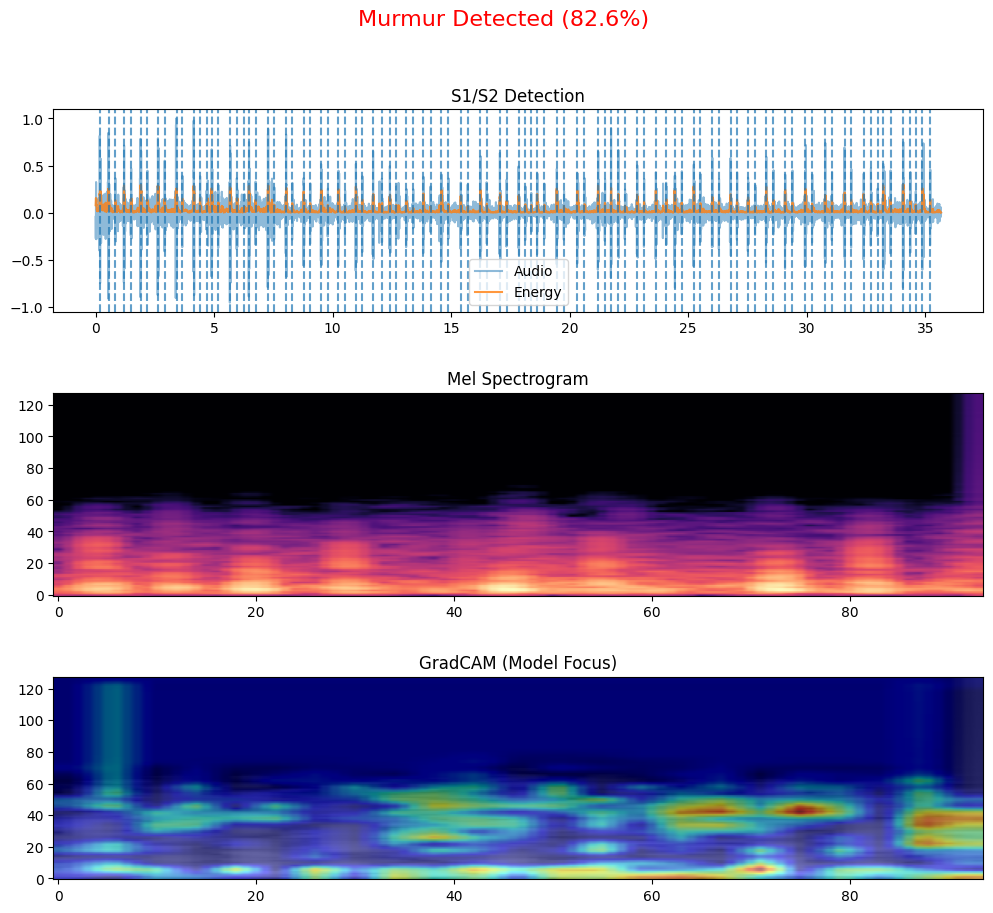

In [ ]:
# ==========================================
# 6b. MASTER EXPLAINABILITY PIPELINE (FINAL CLEAN VERSION)
# ==========================================

import os
import glob
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from scipy.signal import find_peaks

# ------------------------------------------
# 🔥 FOCAL LOSS (ONLY FOR LOADING MODEL)
# ------------------------------------------
def focal_loss(gamma=2., alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        return alpha * tf.pow((1 - p_t), gamma) * bce
    return loss

# ------------------------------------------
# 1. S1/S2 SEGMENTATION (IMPROVED)
# ------------------------------------------
def segment_heart_sounds(y, sr):
    y_norm = y / (np.max(np.abs(y)) + 1e-8)

    energy = -(y_norm**2) * np.log(y_norm**2 + 1e-10)

    window_len = int(sr * 0.02)
    smoothed = np.convolve(energy, np.ones(window_len)/window_len, mode='same')

    threshold = np.mean(smoothed) + 0.3 * np.std(smoothed)

    peaks, _ = find_peaks(
        smoothed,
        distance=int(sr * 0.2),
        height=threshold
    )

    return y_norm, smoothed, peaks

# ------------------------------------------
# 2. GRADCAM (AUTO DETECT LAST CONV)
# ------------------------------------------
def make_gradcam_heatmap(img_array, model):
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer.name
            break

    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# ------------------------------------------
# 3. VISUALIZATION
# ------------------------------------------
def generate_master_report(audio_path, spec_path, model, threshold=0.25):
    print(f"\nProcessing: {os.path.basename(audio_path)}")

    y, sr = librosa.load(audio_path, sr=2000)
    spec = np.load(spec_path)

    # Normalize (same as training)
    spec = (spec - np.mean(spec)) / (np.std(spec) + 1e-6)
    spec_input = np.expand_dims(np.expand_dims(spec, -1), 0)

    # Prediction
    pred = model.predict(spec_input, verbose=0)[0][0]
    label = "Murmur Detected" if pred > threshold else "Normal Heart"
    confidence = pred if pred > threshold else (1 - pred)

    # Segmentation
    y_norm, energy, peaks = segment_heart_sounds(y, sr)

    # GradCAM
    heatmap = make_gradcam_heatmap(spec_input, model)
    heatmap = cv2.resize(heatmap, (spec.shape[1], spec.shape[0]))

    # Plot
    fig, ax = plt.subplots(3, 1, figsize=(12, 10))
    plt.subplots_adjust(hspace=0.4)

    color = "red" if label == "Murmur Detected" else "green"
    fig.suptitle(f"{label} ({confidence:.1%})", color=color, fontsize=16)

    # Waveform + Peaks
    t = np.linspace(0, len(y)/sr, len(y))
    ax[0].plot(t, y_norm, alpha=0.5, label="Audio")
    ax[0].plot(t, energy, alpha=0.8, label="Energy")

    for p in peaks:
        ax[0].axvline(p/sr, linestyle='--', alpha=0.7)

    ax[0].legend()
    ax[0].set_title("S1/S2 Detection")

    # Spectrogram
    ax[1].imshow(spec, aspect='auto', origin='lower', cmap='magma')
    ax[1].set_title("Mel Spectrogram")

    # GradCAM
    ax[2].imshow(spec, aspect='auto', origin='lower', cmap='gray')
    ax[2].imshow(heatmap, aspect='auto', origin='lower', cmap='jet', alpha=0.5)
    ax[2].set_title("GradCAM (Model Focus)")

    plt.show()

# ------------------------------------------
# 4. LOAD SAMPLE
# ------------------------------------------
df = pd.read_csv("data/csv/final_training_dataset.csv")

sample = df.sample(1).iloc[0]
test_npy = sample['spectrogram_path']

file_name = os.path.basename(test_npy)
index_id = file_name.split('_')[1]

audio_candidates = glob.glob(f"data/processed/processed_audio/clean_{index_id}_*.wav")

if len(audio_candidates) == 0:
    raise FileNotFoundError(f"No audio found for index {index_id}")

test_wav = audio_candidates[0]

print("\nUsing sample:")
print("Spectrogram:", test_npy)
print("Audio:", test_wav)

# ------------------------------------------
# 5. LOAD MODEL (FINAL CLEAN)
# ------------------------------------------
model = tf.keras.models.load_model(
    "models/cnn_bilstm_attention_best.keras",
    custom_objects={'loss': focal_loss()},
    compile=False
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=focal_loss()
)
# ------------------------------------------
# 6. RUN REPORT
# ------------------------------------------
generate_master_report(test_wav, test_npy, model)

<div style="font-family: Georgia, serif; font-size: 11pt;">

## 🔬 SHAP Explainability

This step explains model predictions by highlighting important regions in the spectrogram.

---

### ⚙️ What it does

- 📥 Loads trained model and a sample spectrogram  
- 📊 Applies SHAP (DeepExplainer)  
- 🔥 Computes feature importance for each pixel  
- 🖼️ Visualizes important regions  

---

### 🔍 Interpretation

- Left: Original Mel spectrogram  
- Right: SHAP importance map  
- Brighter regions → higher influence on prediction  

---

### 🎯 Significance

- ✔ Identifies **what features the model relies on**  
- ✔ Improves transparency of predictions  
- ✔ Complements GradCAM for deeper insight  

---

✨ Provides pixel-level explanation of murmur detection.

</div>

Loading CNN-BiLSTM-Attention model...
Using spectrogram: .\spectrograms\spec_668_1.npy
Initializing SHAP...
Computing SHAP values...


d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM\RHD_detection\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(1, 128, 94, 1))']
  warnings.warn(msg)
d:\Vaishnavi Peri\RHD_Murmur_8th_sem(2) -BiLSTM\RHD_detection\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(50, 128, 94, 1))']
  warnings.warn(msg)


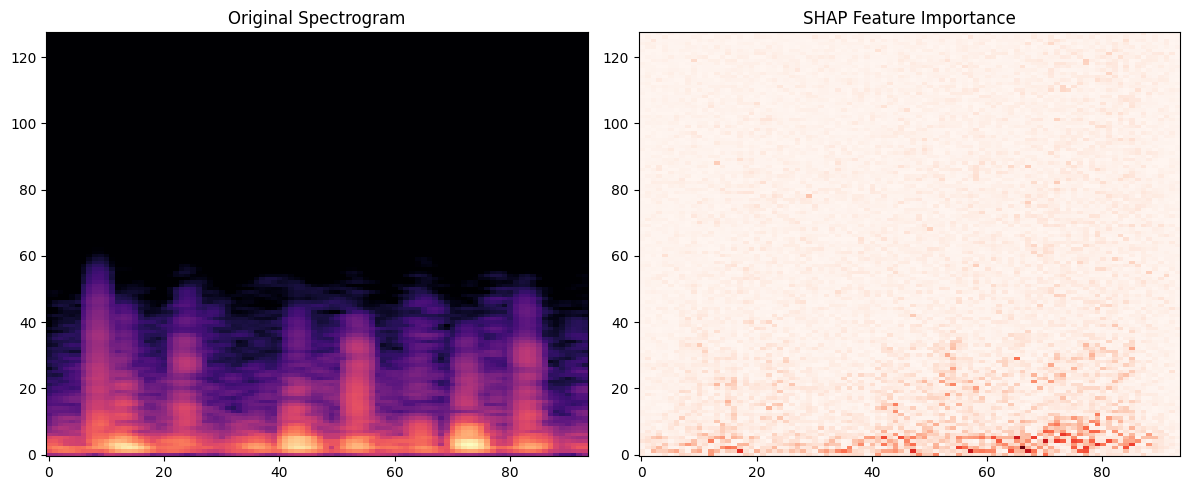

In [ ]:
# ==========================================
# 6c. SHAP EXPLAINABILITY (FINAL CLEAN VERSION)
# ==========================================

import shap
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 🔥 FOCAL LOSS (REQUIRED FOR MODEL LOADING)
# ------------------------------------------
def focal_loss(gamma=2., alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        p_t = y_true*y_pred + (1-y_true)*(1-y_pred)
        return alpha * tf.pow((1 - p_t), gamma) * bce
    return loss

# ------------------------------------------
# 1. LOAD MODEL (UPDATED)
# ------------------------------------------
print("Loading CNN-BiLSTM-Attention model...")

model = tf.keras.models.load_model(
    "models/cnn_bilstm_attention_best.keras",
    custom_objects={'loss': focal_loss()}
)

# ------------------------------------------
# 2. LOAD SAMPLE
# ------------------------------------------
df = pd.read_csv("data/csv/final_training_dataset.csv")

sample = df.sample(1).iloc[0]
test_npy = sample['spectrogram_path']

print("Using spectrogram:", test_npy)

spec = np.load(test_npy)

# ------------------------------------------
# 3. PREPROCESS (MATCH TRAINING)
# ------------------------------------------
spec_norm = (spec - np.mean(spec)) / (np.std(spec) + 1e-6)

spec_input = np.expand_dims(np.expand_dims(spec_norm, axis=-1), axis=0)

# ------------------------------------------
# 4. SHAP EXPLAINER (ROBUST VERSION)
# ------------------------------------------
print("Initializing SHAP...")

# Use small random background (more stable than zeros)
background = np.random.normal(
    0, 1,
    (5, spec.shape[0], spec.shape[1], 1)
)

explainer = shap.GradientExplainer(model, background)

# ------------------------------------------
# 5. COMPUTE SHAP VALUES
# ------------------------------------------
print("Computing SHAP values...")

shap_values = explainer.shap_values(spec_input)

# Handle output format
if isinstance(shap_values, list):
    shap_numpy = shap_values[0]
else:
    shap_numpy = shap_values

# ------------------------------------------
# 6. VISUALIZATION
# ------------------------------------------
plt.figure(figsize=(12, 5))

# Original spectrogram
plt.subplot(1, 2, 1)
plt.imshow(spec, aspect='auto', origin='lower', cmap='magma')
plt.title("Original Spectrogram")

# SHAP importance map
plt.subplot(1, 2, 2)
plt.imshow(
    np.abs(shap_numpy[0, :, :, 0]),
    aspect='auto',
    origin='lower',
    cmap='Reds'
)
plt.title("SHAP Feature Importance")

plt.tight_layout()
plt.show()